In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import h5py
from slope2noise.utils import octave_filtering
from pathlib import Path
from numpy.typing import ArrayLike
import DecayFitNet.python.toolbox.BayesianDecayAnalysis as bda
import DecayFitNet.python.toolbox as decayfitnet
import DecayFitNet.python.toolbox.DecayFitNetToolbox as dfn

from slope2noise.utils import schroeder_backward_int, decay_kernel
from slope2noise.dataclass import *
from slope2noise.generate import *

Load parameters from Georg's dataset 

In [3]:
dataset_path = Path("../../../resources/Georg_3room_FDTD/Common_Slope_Analysis_Results").resolve()
# load the impulse responses
file_path = Path("../../../resources/Georg_3room_FDTD/srirs.mat").resolve()

with h5py.File(file_path, 'r') as mat_file:
    # Get the dataset
    srirs = mat_file['srirDataset']
    # get the impulse responses
    fs = int(np.squeeze(srirs['fs'][:])) # sampling frequnecy
    L = srirs['srirs'][:].shape[1] # length of the impulse responses
    loc_indx = 680   # location index [0, 838]
    ref_rir = srirs['srirs'][0, :, loc_indx]   # assuming that the omnidirectional is the first channel

time_axis = np.arange(0, L) / fs
f_bands = [125, 250, 500, 1000, 2000, 4000, 8000]
i_band = 4

Estimate the Decay parameters using DFN at 1000Hz 

In [5]:
# initialize the decay fit net toolbox
dfn_band = dfn.DecayFitNetToolbox(n_slopes=0, sample_rate=fs, filter_frequencies=[f_bands[i_band]])
# estimate the parameters 
estimated_param, norm_vals_decayfitnet = dfn_band.estimate_parameters(ref_rir, analyse_full_rir=True)
# fit the EDC
ref_edc_decayfitnet = decayfitnet.core.decay_model(torch.from_numpy(estimated_param[0]),
                                                    torch.from_numpy(estimated_param[1])*(norm_vals_decayfitnet.squeeze()),
                                                    torch.from_numpy(estimated_param[2])*(norm_vals_decayfitnet.squeeze()),
                                                    time_axis=torch.from_numpy(time_axis),
                                                    compensate_uli=True,
                                                    backend='torch')

Compare the estimated parameters with those in the dataset

In [7]:
# DecayFitNet finds the optimal number of slopes and set the rest to zero
# pick one random file from the dataset 
filepath = "cs_analysis_results_omni_"+str(f_bands[i_band])+".mat"
# read the mat file
file_path = os.path.join(dataset_path, filepath)
with h5py.File(file_path, 'r') as mfile:
    data = mfile['analysisResults']
    valid_slopes =  np.nonzero(data['tVals_standard'][:, loc_indx])[0]
    valid_slopes_dfn =  np.nonzero(estimated_param[1])[0]
    
    isStandard = True
    if isStandard: 
        t_vals = data['tVals_standard'][valid_slopes, loc_indx] 
        a_vals =  data['aVals_standard'][valid_slopes, loc_indx] 
        n_vals = data['nVals_standard'][..., loc_indx]
    else: 
        t_vals = np.squeeze(data['commonDecayTimes'][:])
        a_vals =  data['aVals'][...,loc_indx] 
        n_vals = data['nVals'][..., loc_indx]

In [53]:
def generate_edc_slope2noise(t_vals: ArrayLike, a_vals: ArrayLike, n_vals: float, time_axis: ArrayLike, compensate_uli:bool = False, 
                             add_noise:bool=False):
    ref_edc_slope2noise = np.zeros_like(time_axis)
    for i_slope in range(len(t_vals)):
            # NOTE: last slope index is interpreted as noise term
            # generate decay envelope
        tau_vals = np.log(10**6) / t_vals[i_slope]
        envelopes = np.exp(-tau_vals * time_axis)
        
        # compensate for the upper limit of integration
        if compensate_uli:
            envelopes -= np.exp(np.log(10**-6) * L / (fs * t_vals[i_slope]))
        weighted_env = envelopes * a_vals[i_slope]
        ref_edc_slope2noise += weighted_env
    if add_noise:
        ref_edc_slope2noise += n_vals * (L - np.arange(L))
    return ref_edc_slope2noise

In [71]:
from importlib import reload
import slope2noise
reload(slope2noise.generate)
from slope2noise.generate import shaped_wgn

print("dataset t_vals: ", t_vals)
print("estimated t_vals: ", estimated_param[0].squeeze()[valid_slopes_dfn])

print("a_vals: ", a_vals)
print("estimated a_vals: ", estimated_param[1].squeeze()[valid_slopes_dfn])

print("n_vals: ", n_vals)
print("estimated n_vals: ", estimated_param[2].squeeze())

ref_edc_slope2noise = generate_edc_slope2noise(estimated_param[0].squeeze(), 
                         np.squeeze(estimated_param[1] * norm_vals_decayfitnet.detach().numpy()), 
                         np.squeeze(estimated_param[2] * norm_vals_decayfitnet.detach().numpy()),
                         time_axis,
                         compensate_uli=True,
                         add_noise=True)

# ref_edc_slope2noise = generate_edc_slope2noise(t_vals,
#                                                a_vals,
#                                                n_vals,
#                                                time_axis,
#                                                add_noise=True,
#                                                compensate_uli=True)

_, rir_slope2noise = shaped_wgn(np.expand_dims(t_vals, [0, -1]), 
                                np.expand_dims(a_vals * norm_vals_decayfitnet.squeeze().detach().numpy(), [0, -1]), 
                                np.expand_dims(n_vals * norm_vals_decayfitnet.squeeze().detach().numpy(), -1), 
                                fs, L)

edc_slope2noise = schroeder_backward_int(rir_slope2noise.squeeze(), normalize=False)

2025-01-29 18:15:09.772 | INFO     | slope2noise.generate:shaped_wgn:88 - Done with kernel generation for slope 1
2025-01-29 18:15:09.779 | INFO     | slope2noise.generate:shaped_wgn:88 - Done with kernel generation for slope 2
2025-01-29 18:15:09.784 | INFO     | slope2noise.generate:shaped_wgn:88 - Done with kernel generation for slope 3


dataset t_vals:  [1.55049969 3.39127965]
estimated t_vals:  [1.2693211 1.2693211]
a_vals:  [9.1861652  0.22181303]
estimated a_vals:  [0.937201 0.937201]
n_vals:  [3.65361309e-09]
estimated n_vals:  3.400021e-17
(3,) ()


Compare the EDC from SRIR filtered at 1000 with the fitted EDC

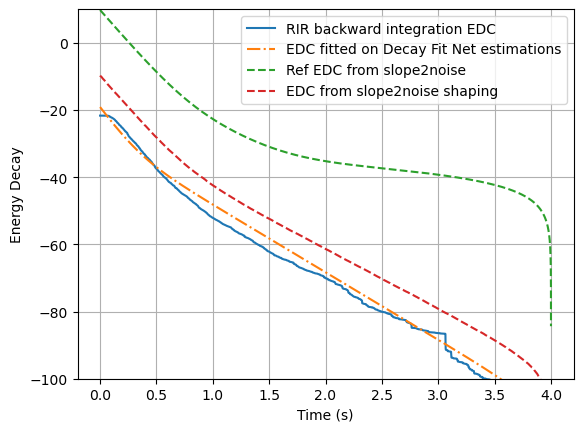

In [69]:
# extract the 1000 Hz band from the impulse response
ref_rir_filt = octave_filtering(ref_rir, fs, f_bands, compensate_filter_energy=False)[:, i_band]
# Use schroeder backward integration to estimate the EDC
ref_filt_int = schroeder_backward_int(ref_rir_filt.squeeze(), normalize=False)

plt.plot(time_axis, 10*np.log10(ref_filt_int), '-', label='RIR backward integration EDC')
plt.plot(time_axis, 10*np.log10(ref_edc_decayfitnet.squeeze()), '-.', label='EDC fitted on Decay Fit Net estimations')
plt.plot(time_axis, 10*np.log10(ref_edc_slope2noise), '--', label='Ref EDC from slope2noise')
plt.plot(time_axis, 10*np.log10(edc_slope2noise), '--', label='EDC from slope2noise shaping')

plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.ylim(-100, 10)
plt.legend()
plt.grid(True)
plt.show()